# AE for representation learning with simulated data

As seen in the introductory document, **AEs** are able to map input to a lower dimensional representation, it is in this regard an unsupervised dimensionality reduction technique, just as **principal component analysis** (PCA). Actually, when an AE has a one-layer encoder, its model is pretty close to that of **PCA** which also minimizes **MSE**. 

In this exercise, we will illustrate the ability of **AEs** to perform dimensionality reduction on a toy dataset. 
Unlike the previous practical, we will not instantiate directly a layer. Instead we will use instances of `torch.Parameter` for the weight matrices ${\mathbf{w}^{(j)}}$ and intercept vectors ${\mathbf{b}^{(j)}}$. The goal is twofold:
 - It shows you that `torch` is quite flexible and that customized layers are not difficult to create,
 - We will be easily able to tie matrices as discussed in the introductory document.

From these variables, we can complete the computation graph by using `torch` calculus functions.

Let us create a first rudimentary **AE** and train it to learn a 2D representation from the following 3D dataset:

<img src="dataset.png" alt="3D dataset" width="400"/>

To complete the exercise, you must fill the gaps in the blocks bellow. 

In these blocks, you will see:
 - a first cell that creates a synthetic dataset where inputs are in 3D,
 - a second cell where a new python class **Basic_AE** is defined,
 - a third cell where an instance of this class is created,
 - a fourth cell, where the model instance is trained,
 - and a final and fifth cell where we visualize results.


**Remark** In these practicals, we will use the exponential linear unit (**ELU**) activation function which approximates **ReLU**, but provides also negative values as activations.

In [1]:
import torch
from sklearn.preprocessing import StandardScaler
import numpy.random as rnd
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)
np.random.seed(42)

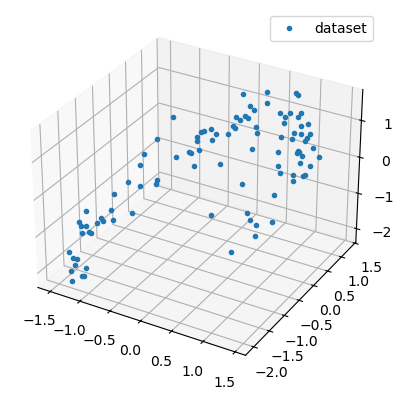

In [3]:
rep = "."


######################
# Dataset generation #
######################

rnd.seed(4)
m = 200
w1, w2 = 0.1, 0.3
noise = 0.1

angles = rnd.rand(m) * 3 * np.pi / 2 - 0.5
data = np.empty((m, 3))
data[:, 0] = np.cos(angles) + np.sin(angles) / 2 + noise * rnd.randn(m) / 2
data[:, 1] = np.sin(angles) * 0.7 + noise * rnd.randn(m) / 2
data[:, 2] = data[:, 0] * w1 + data[:, 1] * w2 + noise * rnd.randn(m)

scaler = StandardScaler()
X_train = scaler.fit_transform(data[:100]).astype('float32')
X_test = scaler.transform(data[100:]).astype('float32')

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot(X_train[:, 0], X_train[:, 1], X_train[:, 2], '.', label='dataset')
ax.legend()
plt.show()

In the block bellow `Basic_AE` class is a child class of `torch.nn.Module` which defines a framework for designing a customized `torch` models. The constructor of the class is already partially written. This constructor is meant to create instances of `torch.nn.Parameters` with appropriate sizes. 

### Q1

Assuming that we build an AE whose **decoder and encoder have only one layer**, fill the gaps in the constructor definition. 
The missing numbers are integers that are elements of the list `unit_nbrs` which contains the input dimension followed by the desired number of units per layer. In this exercise, we thus have `len(unit_nbrs)=2`.

There are also missing instructions in the `Basic_AE.__call__` function. This function will allow an instance of the class to be also a callable object, because neural networks are functions mapping inputs to predictions. In this case the **AE** is meant to map $\mathbf{x}$ to $\tilde{\mathbf{x}}$. Fill the gaps in `Basic_AE.__call__` by using `torch` ops such as `tf.matmul` and `tf.transpose`.

In [4]:
#################################################
# Dimensionality reduction with an auto-encoder #
#################################################

d_in = 3  # input dimensionality
d_hid = 2  # code dimensionality
d_out = d_in  # output dimensionality

activation = torch.nn.ELU()

class Basic_AE(torch.nn.Module):
    def __init__(self, unit_nbrs, name=None):
        super(Basic_AE, self).__init__()
        self.w1 = torch.nn.Parameter(torch.randn([unit_nbrs[0], unit_nbrs[1]]), requires_grad=True)
        self.b1 = torch.nn.Parameter(torch.zeros(unit_nbrs[1]), requires_grad=True)
        self.b2 = torch.nn.Parameter(torch.zeros(unit_nbrs[0]), requires_grad=True)
        self.K = len(unit_nbrs) - 1

    def __call__(self, x):
        z = activation(torch.matmul(x, self.w1) + self.b1)
        x_tilde = activation(torch.matmul(z, torch.transpose(self.w1, 0, 1)) + self.b2)
        return x_tilde

    def coding(self, x):
       z = activation(torch.matmul(x, self.w1) + self.b1)
       return z
        
def loss(target, pred):
    return torch.mean((target - pred)**2)  

If the constructor is correctly written, instantiation should work. 
You should also run unit tests on a small tensor to check if `Basic_AE.__call__` works well. 
To call the function on a tensor $x$ you should instaciante an object (`model`) of class `Basic_AE` and use the functional notation `model(x)`. If you want to use **X_train** (or parts of it), you shoud first transform X_train in a tensor using `torch.tensor` function.

In [5]:
x_train_t = torch.tensor(X_train)
x_test_t = torch.tensor(X_test)

model = Basic_AE([d_in, d_hid], name="Basic_ae")
model(torch.tensor(X_train[0:2]))

tensor([[ 0.4872,  0.3108, -0.8125],
        [-0.2116, -0.1530,  0.7921]], grad_fn=<EluBackward0>)

We prepare now for the training procedure.

In the next cells, we first set the hyperparameters (learning_rate, optimizer, ...). Then, we loop on epochs and we do batch gradient descent. 

### Q2

The missing instructions corresponds to the main elements of the training loop :  
 - reset gradients
 - compute the forward pass
 - backpropagate the loss
 - update the parameters by using the optimizer

If your code is fine, the loss should decrease at each epoch. 

In [6]:
def train_and_eval(model, n_epochs, optimizer, x_train_t, x_test_t, print_loss=False):
    train_loss_history = []
    test_loss_history = []
    loss = torch.nn.MSELoss()
    for epoch in range(n_epochs):
        model.train()  
        optimizer.zero_grad()
        outputs = model(x_train_t)
        train_loss = loss(outputs, x_train_t)
        train_loss.backward()
        optimizer.step()
        
        model.eval()
        train_loss_history.append(train_loss.item())
        test_loss_history.append(loss(model(x_test_t), x_test_t).item())

        if print_loss:
            print("Epoch %d  - \ttrain_loss=%.5f - \ttest_loss=%.5f" % (epoch, train_loss_history[-1], test_loss_history[-1]), end="\n")
    return train_loss_history, test_loss_history

In [7]:
# Model instanciation
model = Basic_AE([d_in, d_hid], name="Basic_ae")

learning_rate=1e-1
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
n_epochs = 1000

train_loss_history, test_loss_history = train_and_eval(model, n_epochs, optimizer, x_train_t, x_test_t, print_loss=True)

Epoch 0  - 	train_loss=4.48081 - 	test_loss=2.99335
Epoch 1  - 	train_loss=2.71759 - 	test_loss=1.76200
Epoch 2  - 	train_loss=1.60816 - 	test_loss=1.01370
Epoch 3  - 	train_loss=0.95440 - 	test_loss=0.60053
Epoch 4  - 	train_loss=0.60192 - 	test_loss=0.40958
Epoch 5  - 	train_loss=0.43607 - 	test_loss=0.34694
Epoch 6  - 	train_loss=0.37471 - 	test_loss=0.34238
Epoch 7  - 	train_loss=0.36157 - 	test_loss=0.36242
Epoch 8  - 	train_loss=0.36980 - 	test_loss=0.39137
Epoch 9  - 	train_loss=0.38859 - 	test_loss=0.41974
Epoch 10  - 	train_loss=0.40975 - 	test_loss=0.44096
Epoch 11  - 	train_loss=0.42598 - 	test_loss=0.45021
Epoch 12  - 	train_loss=0.43169 - 	test_loss=0.44498
Epoch 13  - 	train_loss=0.42422 - 	test_loss=0.42461
Epoch 14  - 	train_loss=0.40340 - 	test_loss=0.39016
Epoch 15  - 	train_loss=0.37037 - 	test_loss=0.34647
Epoch 16  - 	train_loss=0.32808 - 	test_loss=0.30369
Epoch 17  - 	train_loss=0.28504 - 	test_loss=0.27432
Epoch 18  - 	train_loss=0.25425 - 	test_loss=0.26620
Epo

Plot the evolution of the MSE loss w.r.t. time iterations.

### Q3

Try changing the learning rate (1e-1,1e-2,1e-3,1e-5) and discuss the effect on these plots.

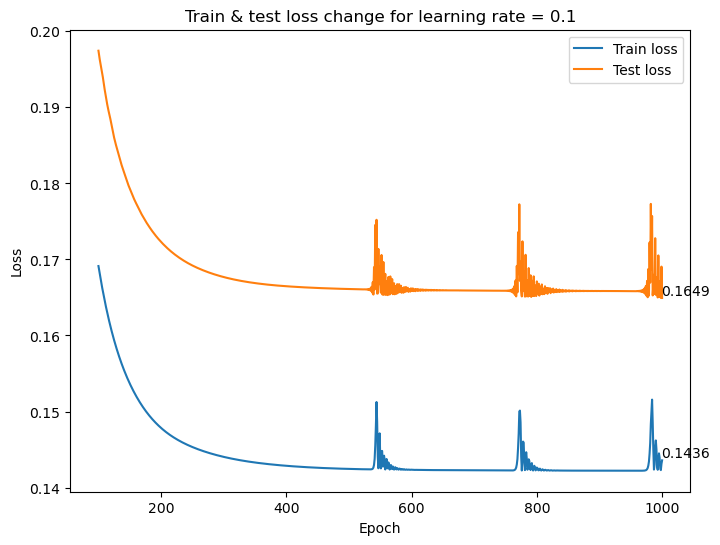

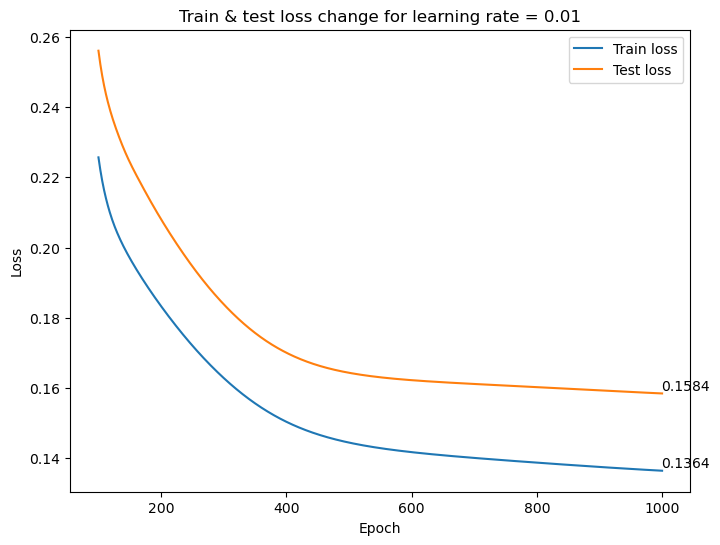

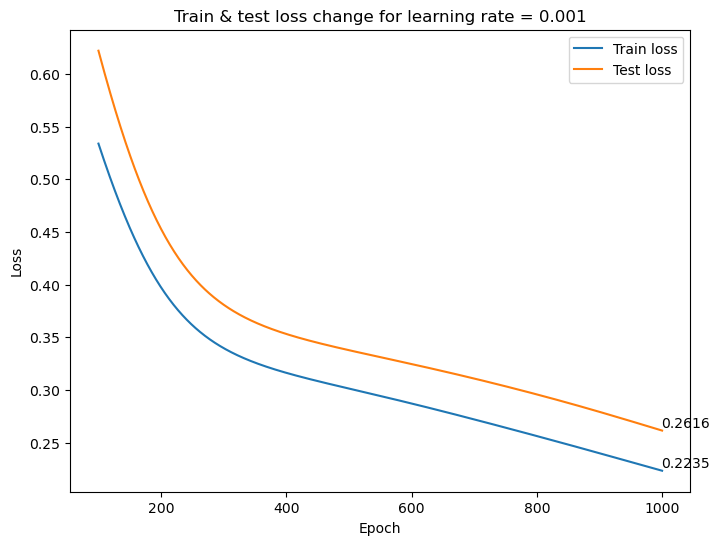

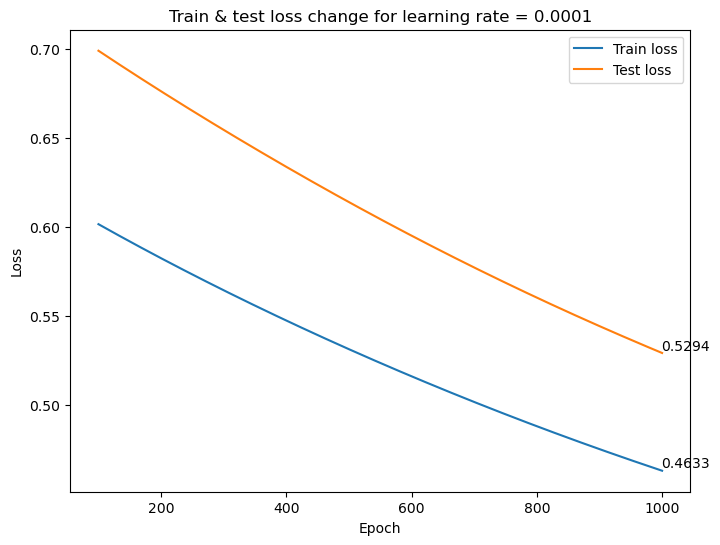

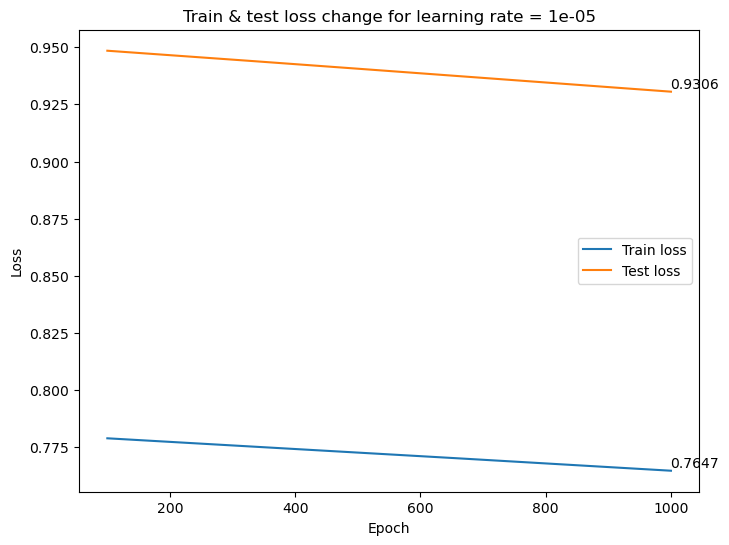

In [8]:
# Plots

# At the beginning the loss is huge, but then drops quickly.
# To avoid an excessively large scale on the Y-axis, we start the visualization from the 100th epoch.
start_epoch = 99
epochs = range(start_epoch + 1, len(train_loss_history) + 1)

for lr in [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]:
    model = Basic_AE([d_in, d_hid], name="Basic_ae")
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_loss_history, test_loss_history = train_and_eval(model, n_epochs, optimizer, x_train_t, x_test_t)
    
    fig = plt.figure(figsize=(8, 6))
    
    plt.plot(epochs, train_loss_history[start_epoch:], label='Train loss')
    plt.plot(epochs, test_loss_history[start_epoch:], label='Test loss')

    x_last = n_epochs - 1
    y_train_last = train_loss_history[-1]
    y_test_last = test_loss_history[-1]
    
    plt.text(x_last, y_train_last,
             f'{y_train_last:.4f}',
             va='bottom', ha='left')
    
    plt.text(x_last, y_test_last,
             f'{y_test_last:.4f}',
             va='bottom', ha='left')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f"Train & test loss change for learning rate = {lr}")
    plt.legend()
    plt.show()

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0">
    
Key observations:
- lr = 0.1 -> convergence is reached after approximately 500 epochs; however, after that, periodic increases and decreases in the loss are observed. This happens because the learning rate is too large, causing gradient descent to take overly large steps and overshoot the region where the loss should decrease.

- lr = 0.01 -> the loss decreases throughout the entire training process and reaches the lowest values among all tested learning rate values. At the same time, the difference compared to lr = 0.1 is minimal.

- lr = 1e-3 -> the loss decreases throughout the entire training process but does not reach the values achieved with lr = 0.01. This indicates a learning rate that is too small, resulting in slow convergence and an insufficient number of training epochs.

- lr = 1e-4 -> the learning rate is very low, and the model learns only weakly.

- lr = 1e-5 -> the learning rate is extremely low; over 1000 epochs, the loss remains almost unchanged.
</div>

### Q5 

Plot these 2D representations and check that the main geometry of the dataset is preserved.
In order to compute the 2D representation, you should add a `coding` function in the `Basic_AE` class that outputs the `z` (hidden representation) value. We apply `.detach().numpy()` on the obtained value in order to isolate it from the computation graph so that no gradients can be computed on top of that. 


In [9]:
best_model = Basic_AE([d_in, d_hid], name="Basic_ae")
optimizer = torch.optim.Adam(best_model.parameters(), lr=1e-2)
_, _ = train_and_eval(best_model, n_epochs, optimizer, x_train_t, x_test_t)

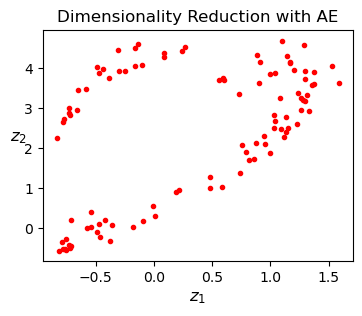

In [10]:
codings_val = best_model.coding(x_train_t).detach().numpy()

fig = plt.figure(figsize=(4, 3))
plt.plot(codings_val[:, 0], codings_val[:, 1], "r.")
plt.xlabel("$z_1$", fontsize=12)
plt.ylabel("$z_2$", fontsize=12, rotation=0)
plt.title('Dimensionality Reduction with AE')
plt.show()

### Q6

Apply **PCA** to the same dataset and compare the results. (You may use the `sklearn` version of PCA but you will need to install the corresponding python module.)

In [11]:
# PCA
from sklearn.decomposition import PCA

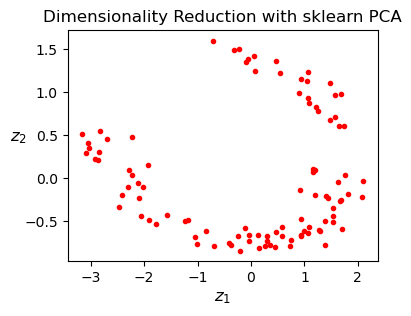

In [12]:
pca = PCA(n_components=2)
codings_pca = pca.fit_transform(x_train_t)

fig = plt.figure(figsize=(4, 3))
plt.plot(codings_pca[:, 0], codings_pca[:, 1], "r.")
plt.xlabel("$z_1$", fontsize=12)
plt.ylabel("$z_2$", fontsize=12, rotation=0)
plt.title('Dimensionality Reduction with sklearn PCA')
plt.show()

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0">
The shape of the plots obtained after dimensionality reduction using the autoencoder and using PCA is absolutely identical. This indicates that the autoencoder is capable of effectively and naturally discovering a latent low-dimensional representation of the original data.
</div>